# Судлах өгөгдлийн анализ (EDA)

Цэвэр өгөгдлийн дотоод бүтэц, хувьсагч хоорондын хамаарлыг судлана. Зорилго: загварчлахаас өмнө гипотез тавих.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/listings_clean.csv')
df.shape

(2965, 20)

## 1. Зорилтот хувьсагч (price_mnt) тархалт

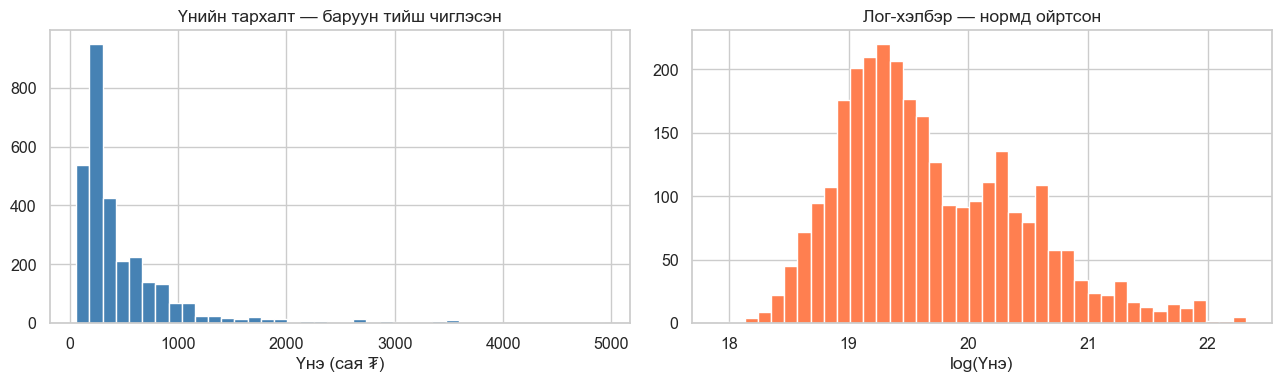

Skewness (өмнө): 3.49
Skewness (лог дараа): 0.73


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df['price_mnt'] / 1e6, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Үнэ (сая ₮)'); axes[0].set_title('Үнийн тархалт — баруун тийш чиглэсэн')
axes[1].hist(df['log_price'], bins=40, color='coral', edgecolor='white')
axes[1].set_xlabel('log(Үнэ)'); axes[1].set_title('Лог-хэлбэр — нормд ойртсон')
plt.tight_layout(); plt.show()

print(f'Skewness (өмнө): {df["price_mnt"].skew():.2f}')
print(f'Skewness (лог дараа): {df["log_price"].skew():.2f}')

**Дүгнэлт**: Үнэ нь хүчтэй баруун тийш чиглэсэн (high skew). Лог-хувиргалт нь нормд ойртуулдаг → регрессийн загварт `log_price`-ийг target болгон ашиглах нь зүйтэй.

## 2. Үнэ vs талбай

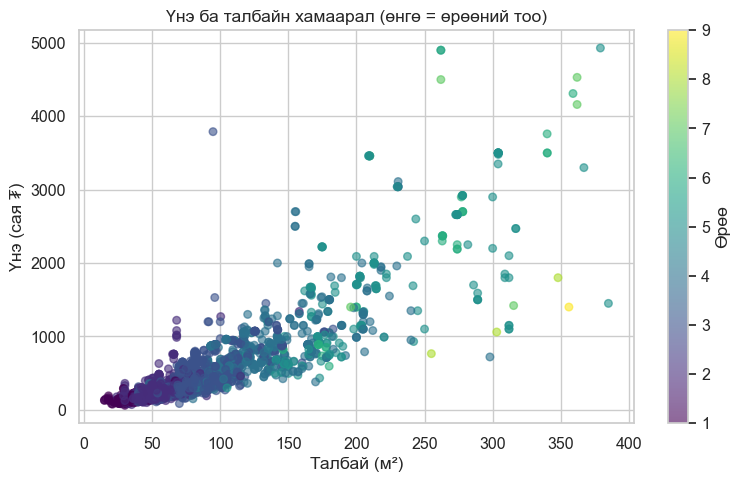

Pearson corr: 0.863


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(df['area_m2'], df['price_mnt'] / 1e6, c=df['rooms'], cmap='viridis', alpha=0.6, s=30)
ax.set_xlabel('Талбай (м²)'); ax.set_ylabel('Үнэ (сая ₮)')
ax.set_title('Үнэ ба талбайн хамаарал (өнгө = өрөөний тоо)')
plt.colorbar(scatter, label='Өрөө')
plt.tight_layout(); plt.show()

corr = df['area_m2'].corr(df['price_mnt'])
print(f'Pearson corr: {corr:.3f}')

## 3. Дүүрэг тус бүрийн үнэ

/var/folders/zn/lhnv34jn6y9_vjf339157wfr0000gn/T/ipykernel_21397/939576257.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='district', y='price_per_m2', order=order, ax=ax, palette='coolwarm')


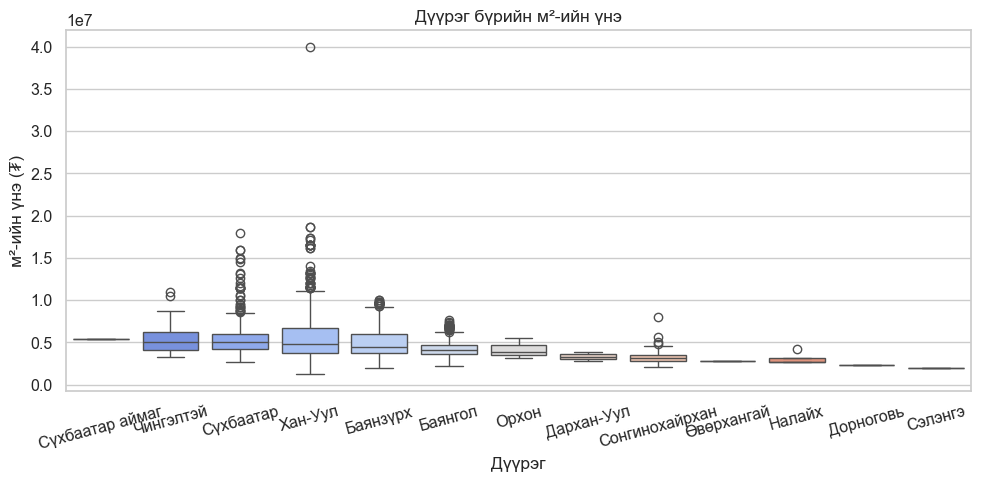

In [4]:
order = df.groupby('district')['price_per_m2'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='district', y='price_per_m2', order=order, ax=ax, palette='coolwarm')
ax.set_ylabel('м²-ийн үнэ (₮)'); ax.set_xlabel('Дүүрэг')
ax.set_title('Дүүрэг бүрийн м²-ийн үнэ')
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

## 4. Барилгын нас vs үнэ

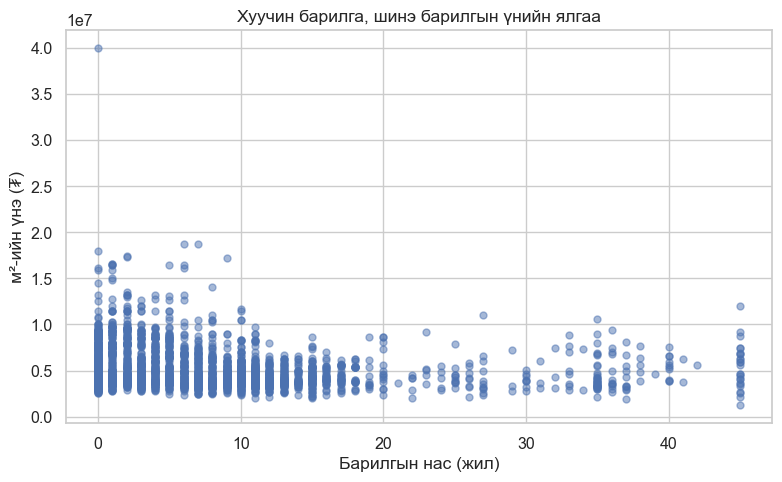

Нас vs м²-ийн үнэ corr: -0.146


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['building_age'], df['price_per_m2'], alpha=0.5, s=25)
ax.set_xlabel('Барилгын нас (жил)'); ax.set_ylabel('м²-ийн үнэ (₮)')
ax.set_title('Хуучин барилга, шинэ барилгын үнийн ялгаа')
plt.tight_layout(); plt.show()

corr = df['building_age'].corr(df['price_per_m2'])
print(f'Нас vs м²-ийн үнэ corr: {corr:.3f}')

## 5. Корреляцийн матриц

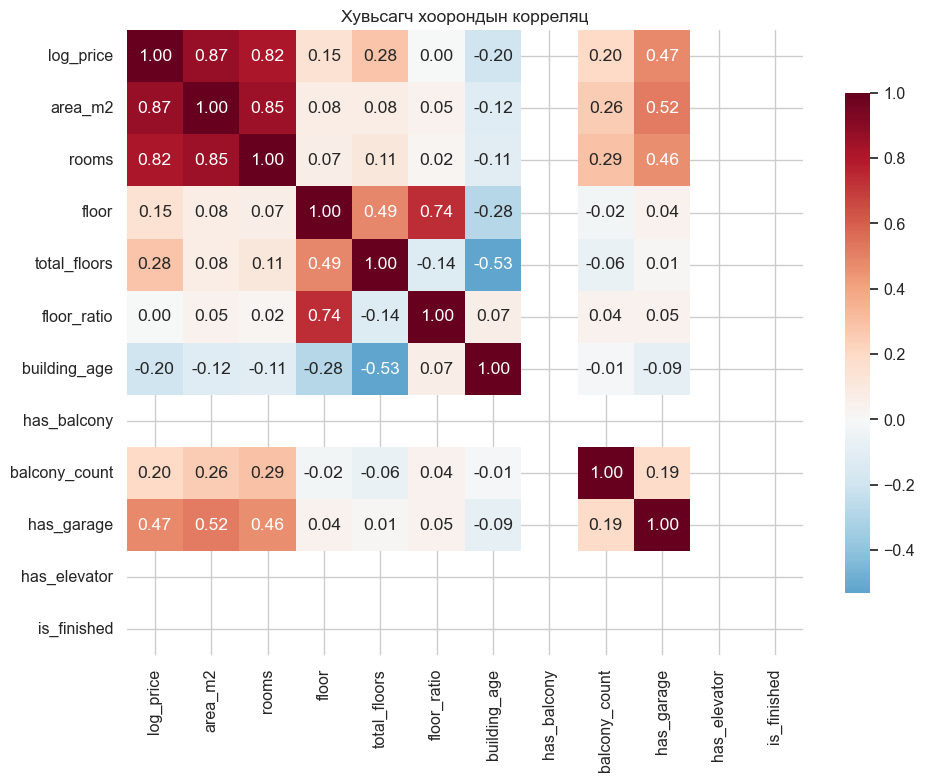

In [6]:
num_cols = ['log_price', 'area_m2', 'rooms', 'floor', 'total_floors', 'floor_ratio',
            'building_age', 'has_balcony', 'balcony_count', 'has_garage', 'has_elevator', 'is_finished']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Хувьсагч хоорондын корреляц')
plt.tight_layout(); plt.show()

## 6. Өрөөний тоо vs үнэ

/var/folders/zn/lhnv34jn6y9_vjf339157wfr0000gn/T/ipykernel_21397/1098792778.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='rooms', y='price_mnt', ax=ax, palette='Blues')


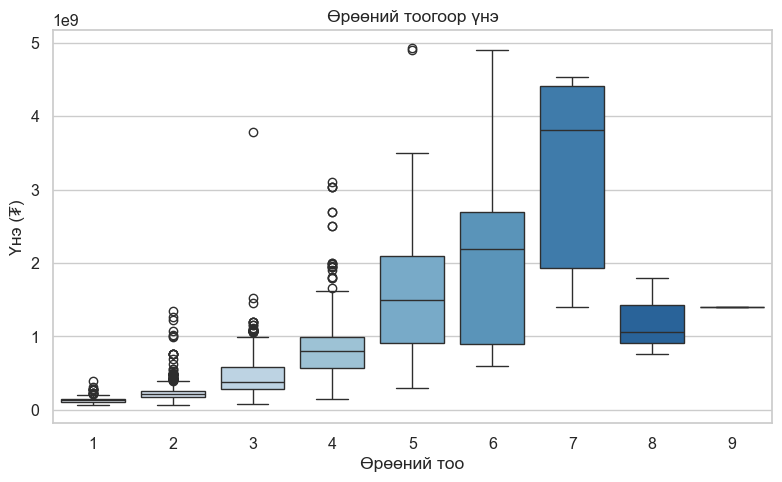

,n,median_price_M
rooms,,
1,213,129.0
2,1122,210.0
3,991,380.0
4,419,795.6
5,177,1500.0
6,33,2190.0
7,6,3810.0
8,3,1060.0
9,1,1400.0


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='rooms', y='price_mnt', ax=ax, palette='Blues')
ax.set_ylabel('Үнэ (₮)'); ax.set_xlabel('Өрөөний тоо')
ax.set_title('Өрөөний тоогоор үнэ')
plt.tight_layout(); plt.show()

df.groupby('rooms').agg(n=('price_mnt','count'), median_price_M=('price_mnt', lambda x: x.median()/1e6)).round(1)

## 7. Гипотезүүд (загварчлахаас өмнөх)

EDA-аас үндэслэн дараах гипотезийг тавьж байна:

1. **Талбай**: үнэтэй хамгийн хүчтэй эерэг хамааралтай (ойролцоогоор r > 0.7)
2. **Дүүрэг**: Сүхбаатар, Хан-Уул дүүрэг хамгийн өндөр м²-ийн үнэтэй
3. **Барилгын нас**: сөрөг хамаарал — шинэ барилга илүү үнэтэй
4. **Цахилгаан шат, гараж, тагт**: үнэд эерэг нөлөөтэй
5. **Лог-хувиргалт**: log(үнэ)-ийг target болгох нь шугаман загварт илүү тохиромжтой

Эдгээрийг `04_models.ipynb`-д харьцуулсан загвараар шалгана.